In [1]:
# Finite field F = Z/107Z
p = 107
F = GF(p)

# Example: polynomial ring in n variables (X1,...,Xn)
# You can adjust n and names as needed.
n = 2  # for example; change to your desired number of variables
R = PolynomialRing(F, n, 'x')
R


Multivariate Polynomial Ring in x0, x1 over Finite Field of size 107

In [2]:
K = Frac(R)
x=R.gens()
x

(x0, x1)

In [3]:
f=x[0]+5*x[1]
g=x[0]*x[1]+3
h=K(f)/K(g)
h

(x0 + 5*x1)/(x0*x1 + 3)

In [4]:
def restricting_rational_function_to_line(h, betas, sigmas, alpha, p=107, return_int=True):
    """
    Restrict a 2-variable rational function h(X,Y) over GF(p) to the line
    psi(x) = (x, β2*(x - σ1) + σ2), then evaluate at x = alpha.

    betas:  [β2]      (list of length 1)
    sigmas: [σ1, σ2]  (list of length 2)
    alpha:  element of GF(p) or integer

    Returns h(psi(alpha)) in GF(p) or as int if return_int=True.
    """

    F = GF(p)
    sigmas = [F(s) for s in sigmas]
    betas  = [F(b) for b in betas]
    alpha  = F(alpha)

    if len(sigmas) != 2:
        raise ValueError("For n=2, sigmas must be [σ1, σ2].")
    if len(betas) != 1:
        raise ValueError("For n=2, betas must be [β2].")

    sigma1, sigma2 = sigmas
    beta2 = betas[0]

    # h is in Frac(R) where R = F[X,Y]
    num = h.numerator()
    den = h.denominator()
    R = num.parent()
    X, Y = R.gens()

    # Polynomial ring in t
    S.<t> = PolynomialRing(F)

    # Images under psi: X -> t, Y -> β2*(t-σ1) + σ2
    X_image = t
    Y_image = beta2*(t - sigma1) + sigma2

    phi = R.hom([X_image, Y_image], S)

    num_t = phi(num)
    den_t = phi(den)

    num_val = num_t(alpha)
    den_val = den_t(alpha)

    if den_val == 0:
        # Pole: h(psi(alpha)) is undefined
        return None

    value = num_val / den_val   # in F

    if return_int:
        return int(value)
    else:
        return value


In [5]:
sigma=[2,3];
beta=[7];
alphas=[1,2,3,4,5];
results = {}  # dictionary: i -> list of (alpha, value)
for i in range(8):
    sigma_i = [F(2)^i, F(3)^i]  # sigma^(i) = [2^i, 3^i] in GF(107)
    line_values = []
    for a in alphas:
        val = restricting_rational_function_to_line(h, beta, sigma_i, a, p=p, return_int=True)
        line_values.append((a, val))
    results[i] = {
        "sigma": sigma_i,
        "values": line_values
    }

results


{0: {'sigma': [1, 1], 'values': [(1, 55), (2, 36), (3, 15), (4, 33), (5, 95)]},
 1: {'sigma': [2, 3], 'values': [(1, 19), (2, 97), (3, 47), (4, 54), (5, 68)]},
 2: {'sigma': [4, 9], 'values': [(1, 66), (2, 95), (3, 49), (4, 4), (5, 99)]},
 3: {'sigma': [8, 27], 'values': [(1, 17), (2, 78), (3, 68), (4, 1), (5, 27)]},
 4: {'sigma': [16, 81],
  'values': [(1, 77), (2, 51), (3, 81), (4, 25), (5, 29)]},
 5: {'sigma': [32, 29],
  'values': [(1, 82), (2, 66), (3, 6), (4, 78), (5, 50)]},
 6: {'sigma': [64, 87],
  'values': [(1, 34), (2, 31), (3, 77), (4, 6), (5, 69)]},
 7: {'sigma': [21, 47],
  'values': [(1, 86), (2, 0), (3, 41), (4, 2), (5, 106)]}}

In [6]:
for i in range(8):
    print(f"Line L_{i} with sigma^{i} = {results[i]['sigma']}")
    for a, v in results[i]['values']:
        print(f"  x = {a} -> h(psi_{i}({a})) = {v}")
    print()


Line L_0 with sigma^0 = [1, 1]
  x = 1 -> h(psi_0(1)) = 55
  x = 2 -> h(psi_0(2)) = 36
  x = 3 -> h(psi_0(3)) = 15
  x = 4 -> h(psi_0(4)) = 33
  x = 5 -> h(psi_0(5)) = 95

Line L_1 with sigma^1 = [2, 3]
  x = 1 -> h(psi_1(1)) = 19
  x = 2 -> h(psi_1(2)) = 97
  x = 3 -> h(psi_1(3)) = 47
  x = 4 -> h(psi_1(4)) = 54
  x = 5 -> h(psi_1(5)) = 68

Line L_2 with sigma^2 = [4, 9]
  x = 1 -> h(psi_2(1)) = 66
  x = 2 -> h(psi_2(2)) = 95
  x = 3 -> h(psi_2(3)) = 49
  x = 4 -> h(psi_2(4)) = 4
  x = 5 -> h(psi_2(5)) = 99

Line L_3 with sigma^3 = [8, 27]
  x = 1 -> h(psi_3(1)) = 17
  x = 2 -> h(psi_3(2)) = 78
  x = 3 -> h(psi_3(3)) = 68
  x = 4 -> h(psi_3(4)) = 1
  x = 5 -> h(psi_3(5)) = 27

Line L_4 with sigma^4 = [16, 81]
  x = 1 -> h(psi_4(1)) = 77
  x = 2 -> h(psi_4(2)) = 51
  x = 3 -> h(psi_4(3)) = 81
  x = 4 -> h(psi_4(4)) = 25
  x = 5 -> h(psi_4(5)) = 29

Line L_5 with sigma^5 = [32, 29]
  x = 1 -> h(psi_5(1)) = 82
  x = 2 -> h(psi_5(2)) = 66
  x = 3 -> h(psi_5(3)) = 6
  x = 4 -> h(psi_5(4)) 

In [13]:
import matplotlib.pyplot as plt

def plot_sampled_lines_matplotlib(h, p=107):
    F = GF(p)
    betas = [7]
    alphas = [1, 2, 3, 4, 5]

    # rainbow palette + darker custom colors
    base_colors = plt.cm.tab10.colors  # Matplotlib built-in nice palette
    custom_colors = [
        base_colors[0],   # L0
        '#00008B',        # L1 dark blue
        '#8B0000',        # L2 dark red
        '#006400',        # L3 dark green
        '#4B0082',        # L4 indigo
        base_colors[5],   # L5
        base_colors[6],   # L6
        base_colors[7],   # L7
    ]

    fig, ax = plt.subplots(figsize=(7, 7))

    results = {}

    for i in range(8):
        sigmas_i = [F(2)^i, F(3)^i]
        color = custom_colors[i]
        x_points = []
        y_points = []

        vals = []

        for a in alphas:
            aF = F(a)

            # psi_i(a)
            x_val = int(aF)
            y_val = int(betas[0] * (aF - sigmas_i[0]) + sigmas_i[1])

            x_points.append(x_val)
            y_points.append(y_val)

            # label each point
            ax.text(x_val+0.05, y_val+0.5, f"({x_val},{y_val})",
                    color=color, fontsize=7)

            # h(psi(a))
            val = restricting_rational_function_to_line(
                h, betas, sigmas_i, a, p=p, return_int=True
            )
            vals.append((a, val))

        # scatter plot for line i
        ax.scatter(x_points, y_points, color=color, s=60, label=f"L_{i}")
        results[i] = {"sigma": sigmas_i, "values": vals}

    # axis labels with LaTeX
    ax.set_xlabel(r"$\alpha_j$", fontsize=16)
    ax.set_ylabel(r"$\mathcal{L}_i$", fontsize=16)

    # integer ticks only
    ax.set_xticks(alphas)
    ax.set_ylim(bottom=min(0, min(y_points)-3))

    # clean legend
    ax.legend(title="Lines", fontsize=10)

    plt.grid(True, linestyle='--', alpha=0.2)
    plt.show()

    return results


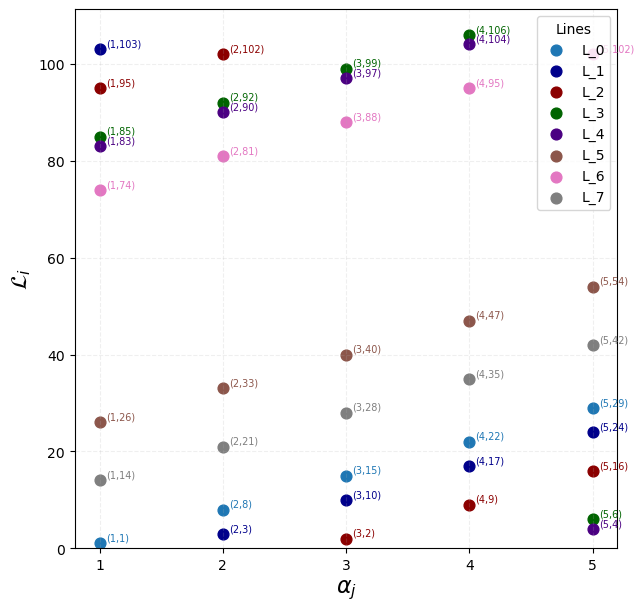

{0: {'sigma': [1, 1], 'values': [(1, 55), (2, 36), (3, 15), (4, 33), (5, 95)]},
 1: {'sigma': [2, 3], 'values': [(1, 19), (2, 97), (3, 47), (4, 54), (5, 68)]},
 2: {'sigma': [4, 9], 'values': [(1, 66), (2, 95), (3, 49), (4, 4), (5, 99)]},
 3: {'sigma': [8, 27], 'values': [(1, 17), (2, 78), (3, 68), (4, 1), (5, 27)]},
 4: {'sigma': [16, 81],
  'values': [(1, 77), (2, 51), (3, 81), (4, 25), (5, 29)]},
 5: {'sigma': [32, 29],
  'values': [(1, 82), (2, 66), (3, 6), (4, 78), (5, 50)]},
 6: {'sigma': [64, 87],
  'values': [(1, 34), (2, 31), (3, 77), (4, 6), (5, 69)]},
 7: {'sigma': [21, 47],
  'values': [(1, 86), (2, 0), (3, 41), (4, 2), (5, 106)]}}

In [15]:
vals = plot_sampled_lines_matplotlib(h, p=107)
vals


In [22]:
import plotly.graph_objs as go

def plot_restriction_3d_plotly(h, p=107):
    F = GF(p)
    betas = [7]
    alphas = [1, 2, 3, 4, 5]

    base_colors = [
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
        "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"
    ]
    custom_colors = [
        base_colors[0],    # L0
        "#00008B",         # L1 dark blue
        "#8B0000",         # L2 dark red
        "#006400",         # L3 dark green
        "#4B0082",         # L4 indigo
        base_colors[5],    # L5
        base_colors[6],    # L6
        base_colors[7],    # L7
    ]

    traces = []

    for i in range(8):
        sigmas_i = [F(2)^i, F(3)^i]
        color = custom_colors[i]

        xs = []
        ys = []   # line index i
        zs = []   # h(psi_i(alpha))
        hover = []

        for a in alphas:
            aF = F(a)
            x_val = int(aF)
            val = restricting_rational_function_to_line(
                h, betas, sigmas_i, a, p=p, return_int=True
            )

            xs.append(x_val)
            ys.append(i)
            zs.append(val)

            hover.append(
                f"L_{i}<br>alpha={x_val}<br>h(psi_i(alpha))={val}"
            )

        traces.append(
            go.Scatter3d(
                x=xs,
                y=ys,
                z=zs,
                mode="markers+lines",
                marker=dict(size=5, color=color),
                line=dict(width=2, color=color),
                name=f"L_{i}",
                text=hover,
                hoverinfo="text"
            )
        )

    fig = go.Figure(data=traces)

    fig.update_layout(
        scene=dict(
            xaxis_title="alpha_j",
            yaxis_title="line index i",
            zaxis_title="h(psi_i(alpha))"
        ),
        title="3D view of restricted rational function",
        legend_title="Lines",
        template="plotly_white",
        height=700
    )

    fig.show()


In [23]:
plot_restriction_3d_plotly(h, p=107)


In [32]:
from mpl_toolkits.mplot3d import Axes3D  # noqa
import matplotlib.pyplot as plt

def plot_h_and_lines_3d_matplotlib(h, p=107, max_coord=20, alphas=None):
    F = GF(p)
    betas = [7]
    if alphas is None:
        alphas = [1,2,3,4,5]

    base_colors = plt.cm.tab10.colors
    custom_colors = [
        base_colors[0],
        "#00008B",
        "#8B0000",
        "#006400",
        "#4B0082",
        base_colors[5],
        base_colors[6],
        base_colors[7],
    ]

    fig = plt.figure(figsize=(9,7))
    ax = fig.add_subplot(111, projection='3d')

    # --- (1) Surface h(x,y) ---
    num = h.numerator()
    den = h.denominator()
    R = num.parent()
    X, Y = R.gens()

    Xs, Ys, Zs = [], [], []
    for xi in range(max_coord+1):
        for yi in range(max_coord+1):
            xF, yF = F(xi), F(yi)
            dval = den(xF, yF)
            if dval != 0:
                zval = num(xF, yF) / dval
                Xs.append(xi)
                Ys.append(yi)
                Zs.append(int(zval))

    ax.scatter(Xs, Ys, Zs, c='lightgray', s=8, alpha=0.35, label='h(x,y)')

    # --- (2) Lines L_i and sample points ---
    for i in range(8):
        color = custom_colors[i]
        sigmas_i = [F(2)**i, F(3)**i]

        xs_line, ys_line, zs_line = [], [], []

        for xi in range(max_coord+1):
            xF = F(xi)
            yF = betas[0] * (xF - sigmas_i[0]) + sigmas_i[1]
            y_int = int(yF)

            z_int = restricting_rational_function_to_line(h, betas, sigmas_i, xi, p=p)

            xs_line.append(xi)
            ys_line.append(y_int)
            zs_line.append(z_int)

        # Plot the line
        ax.plot(xs_line, ys_line, zs_line, color=color, linewidth=2, label=f"L_{i}")

        # Highlight α_j points
        for a in alphas:
            aF = F(a)
            yF = betas[0] * (aF - sigmas_i[0]) + sigmas_i[1]
            y_int = int(yF)
            z_int = restricting_rational_function_to_line(h, betas, sigmas_i, a, p=p)

            ax.scatter(a, y_int, z_int, color=color, s=60, edgecolors='k')

    # --- Axis labels ---
    ax.set_xlabel(r"$x$", fontsize=14)
    ax.set_ylabel(r"$y$", fontsize=14)
    ax.set_zlabel(r"$h(x,y)$", fontsize=14)

    # --- Title + Legend ---
    ax.set_title(r"3D View: $h(x,y)$ with restrictions to lines $L_i$", fontsize=14)
    ax.legend(loc='upper left', fontsize=8)

    # --- ✔ FIXED X-AXIS TICKS ---
    ax.set_xticks(alphas)  
    ax.set_xticklabels([rf"$\alpha_{j}$" for j in range(1, len(alphas)+1)])

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_13253/313443040.py:87: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



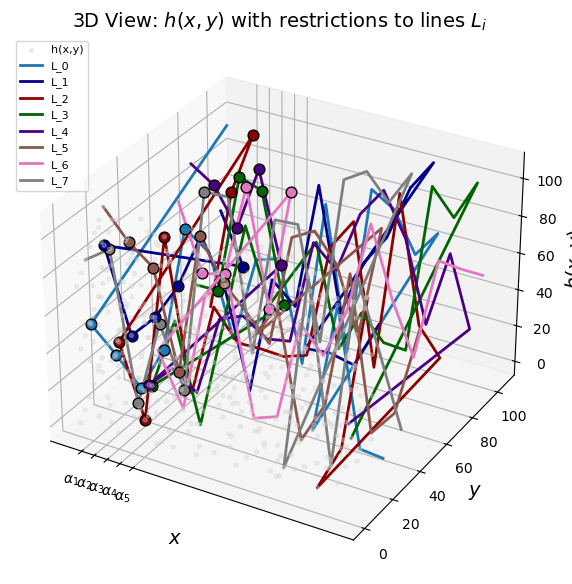

In [33]:
vals=plot_h_and_lines_3d_matplotlib(h,p)
vals